# Simulation Run Log Analysis and Visualization for AWS DeepRacer

This notebook walks through how you can analyze and debug using the AWS DeepRacer Simulation logs. 

It borrows heavily from the official 400L AWS DeepRacer Workshop content, located [here](https://catalog.us-east-1.prod.workshops.aws/workshops/66473261-de66-42a1-b280-3e0ec87aee26/en-US/account-access)

This notebook should work for both discrete and continuous action spaces, and for both training logs and evaluation logs.  

**This version of the notebook is optimized for manually downloaded logs**. If you are running this notebook on SageMaker under your AWS account, use the `DeepRacer Log Analysis.ipynb` notebook file instead. 

In [1]:
# Update boto3 & awscli to the latest version(s) 
!pip install --upgrade boto3
!pip install --upgrade awscli
# Install shapely (used later to draw the track outline)
!pip install shapely

# Fetch dependencies
import ast
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import boto3
import shutil
import os
import subprocess
import glob
import math
import tarfile
import requests
import json
%matplotlib inline

#Pull in the Shapely library
from shapely.geometry import Point, Polygon
from shapely.geometry.polygon import LinearRing, LineString

# Pull in log analysis helpers and some OS tools for filesystem path parsing
from log_analysis import *
from os import listdir
from os.path import isfile, join

Looking in indexes: https://pypi.org/simple, https://pip.repos.neuron.amazonaws.com
Looking in indexes: https://pypi.org/simple, https://pip.repos.neuron.amazonaws.com
Looking in indexes: https://pypi.org/simple, https://pip.repos.neuron.amazonaws.com


# Unpack Your DeepRacer Model And Logs

In [2]:
log_dir = 'local_logs' # Directory inside deepracer-deepstats where your log .tar.gz file is stored
logfile = 'SODA18-clone-training_job_uy_8icCFRcaz0EVgilGGTg_logs.tar.gz'

is_training = True  ## Make this False if you want to do log analysis on Evaluation logs.

In [3]:
# Within the log directory, ensure there is an empty subdirectory called 'logs'
!mkdir -p {'./' + log_dir + '/logs'}
!rm -rf {log_dir + '/logs/*'} # Make sure this subdirectory is empty

tarpath = log_dir + '/' + logfile
outpath = log_dir + '/logs'

# Unpack the tarball into the new logs subdirectory
!tar -xf $tarpath -C $outpath

# Determine the model UUID (will be the name of the new directory under 'logs')
uuid = !ls {outpath + '/'}
uuid = uuid[0] # Pull first result (there should be only one directory present anyway)
full_path = outpath + '/' + uuid
print('Model UUID: {}'.format(uuid))
print('Full path to logs: {}'.format(full_path))

Model UUID: f8601b44-29dd-47d1-909d-6165bfef8773
Full path to logs: local_logs/logs/f8601b44-29dd-47d1-909d-6165bfef8773


In [4]:
# Locate the simtrace logs (these will be stored under a different subdirectory depending on whether 
# we are analyzing training logs or evaluation logs)
simtrace_path = full_path + '/sim-trace/training/training-simtrace/'
if not is_training:
    simtrace_path = '/sim-trace/evaluation/*/evaluation-simtrace/'
merged_simtrace_path = "./logs/deepracer-{}.csv".format(uuid)

In [5]:
# Downloading log data to a local .tar.tgz file from the DeepRacer console 
# (without also exporting the model files to S3) mean we do not have a 
# model_metadata.json file we can reference. We have to parse the raw SageMaker
# or RoboMaker logs for this information (which is what the code below is doing)

# Read raw log file into a string
raw_logs = !cat {full_path + '/logs/training/*-sagemaker.log'}

# Pull sensor data
raw_sensors = ''
for line in raw_logs:
    if line.startswith('Sensor list'):
        raw_sensors = line
        raw_sensors = raw_sensors.split(',') # Model data is a comma separated list
        break

# Pull action space data
raw_actions = ''
for line in raw_logs: 
    if line.startswith('Action space from file'):
        raw_actions = line.split('Action space from file: ')[1] # Strip leading statement
        raw_actions = ast.literal_eval(raw_actions) # Actions are a string but can be directly converted to a dict()
        break

# Parse other model metadata (sensors, neural network, simapp version, etc...)
# This is ugly code, feel free to rewrite if you are a regex wizard
model_metadata = dict()
model_metadata['sensor'] = ast.literal_eval(raw_sensors[0].split(' ')[2])
model_metadata['neural_network'] = raw_sensors[1].split(' ')[2]
model_metadata['version'] = raw_sensors[2].split(' ')[2].split('.')[0]
model_metadata['training_algorithm'] = raw_sensors[3].split(' ')[2]
model_metadata['action_space_type'] = raw_sensors[4].split(' ')[2]
model_metadata['preprocess_type'] = 'GREY_SCALE' # Set to a fixed value for now
model_metadata['regional_parameters'] = [0,0,0,0] # Set to a fixed value for now
model_metadata['action_space'] = raw_actions

# Confirm that the model metadata looks OK
model_metadata

{'sensor': ['FRONT_FACING_CAMERA'],
 'neural_network': 'DEEP_CONVOLUTIONAL_NETWORK_SHALLOW',
 'version': '5',
 'training_algorithm': 'clipped_ppo',
 'action_space_type': 'continuous',
 'preprocess_type': 'GREY_SCALE',
 'regional_parameters': [0, 0, 0, 0],
 'action_space': {'steering_angle': {'high': 30, 'low': -30},
  'speed': {'high': 4, 'low': 1}}}

### Combine all the simtrace `.csv` files into a single file

In [6]:
# Create logs folder, if it doesn't already exist
!mkdir -p logs

# First, build path to sim-trace files
simtrace_string = full_path + '/sim-trace/training/training-simtrace/*.csv'

def get_sort_csv_file():
    # TODO: Add support for evaluation simtrace
    sim_trace_csvs = glob.glob(simtrace_string)
    csvs_with_ids = [(int(os.path.basename(file).split("-")[0]), file) for file in sim_trace_csvs]
    csvs_sorted = sorted(csvs_with_ids, key=lambda csvs_with_ids: csvs_with_ids[0])
    return [csv_file[1] for csv_file in csvs_sorted]
    
def merge_csv_files(output_file_path):
    csv_files = get_sort_csv_file()
    header_saved = False
    with open(output_file_path, 'w') as fout:
        for csv_file in csv_files:
            with open(csv_file) as fin:
                header = next(fin)
                if not header_saved:
                    fout.write(header)
                    header_saved = True
                for line in fin:
                    line = re.sub(r'(\[[^\]]*\])', r'"\1"', line, flags=re.M)
                    fout.write(line)

merge_csv_files(merged_simtrace_path)
!tail -n 3 $merged_simtrace_path

999,54.0,7.609469455525765,2.286205989475444,95.11841705371373,24.06294387731456,2.557127961269834,"[24.06294387731456, 2.557127961269834]",-2.137560938685287,False,False,34.57478641976547,35,17.709159380834848,4679.963,in_progress,0.0
999,55.0,7.631835034020904,2.383127997293766,96.57951148609207,18.052736000908453,1.0,"[18.052736000908453, 1.0]",-1.8186962199346461,False,False,34.65734818702042,35,17.709159380834848,4680.045,in_progress,0.0
999,56.0,7.643049841148542,2.493050715100674,99.60041051365337,30.0,1.0,"[30.0, 1.0]",-2.1240198827836827,True,False,35.131448459224686,36,17.709159380834848,4680.108,off_track,0.0


## Load Track Data (Waypoints)

In [7]:
ListFiles = [f for f in listdir("tracks/") if isfile(join("tracks/", f))]

# Print a list of tracks (one per line)
for item in ListFiles:
    print(item)

H_track.npy
2022_march_open_cw.npy
2022_april_open_ccw.npy
2022_october_pro_ccw.npy
2022_august_open_ccw.npy
penbay_open_ccw.npy
reinvent_base.npy
jyllandsringen_open_cw.npy
caecer_loop.npy
reInvent2019_wide_cw.npy
Canada_Training.npy
2022_march_pro_ccw.npy
reInvent2019_wide.npy
2022_june_pro_ccw.npy
2022_march_open_ccw.npy
Vegas_track.npy
2022_may_open_ccw.npy
Straight_track.npy
2022_april_pro_ccw.npy
ChampionshipCup2019_track.npy
London_Loop_Train.npy
New_York_Track.npy
AWS_track.npy
2022_october_pro_cw.npy
Austin.npy
arctic_pro_cw.npy
morgan_pro.npy
penbay_open.npy
Singapore.npy
red_star_pro_ccw.npy
reInvent2019_wide_mirrored.npy
2022_may_pro_ccw.npy
2022_summit_speedway_cw.npy
2022_september_pro_cw.npy
reInvent2019_track_ccw.npy
Virtual_May19_Train_track.npy
arctic_open.npy
dubai_open.npy
Belille.npy
Monaco.npy
thunder_hill_pro_cw.npy
2022_october_open_ccw.npy
Bowtie_track.npy
2022_april_open_cw.npy
Mexico_track.npy
2022_april_pro_cw.npy
jyllandsringen_pro_cw.npy
red_star_pro_cw.np

In [8]:
def get_track_waypoints(track_name):
    return np.load("tracks/%s.npy" % track_name)


# Pull the track name from the robomaker logs
raw_robo_logs = !cat {full_path + '/logs/training/*-robomaker.log'}

for line in raw_robo_logs:
    if line.startswith('World name'):
        trackname = line.split(':')[1].strip() # Pull out track name

waypoints = get_track_waypoints(trackname)
waypoints.shape

print(trackname)

reinvent_base


## Visualize the Track and Waypoints

In [9]:
def plot_points(ax, points):
    ax.scatter(points[:-1,0], points[:-1,1], s=1)
    for i,p in enumerate(points):
        ax.annotate(i, (p[0], p[1]))

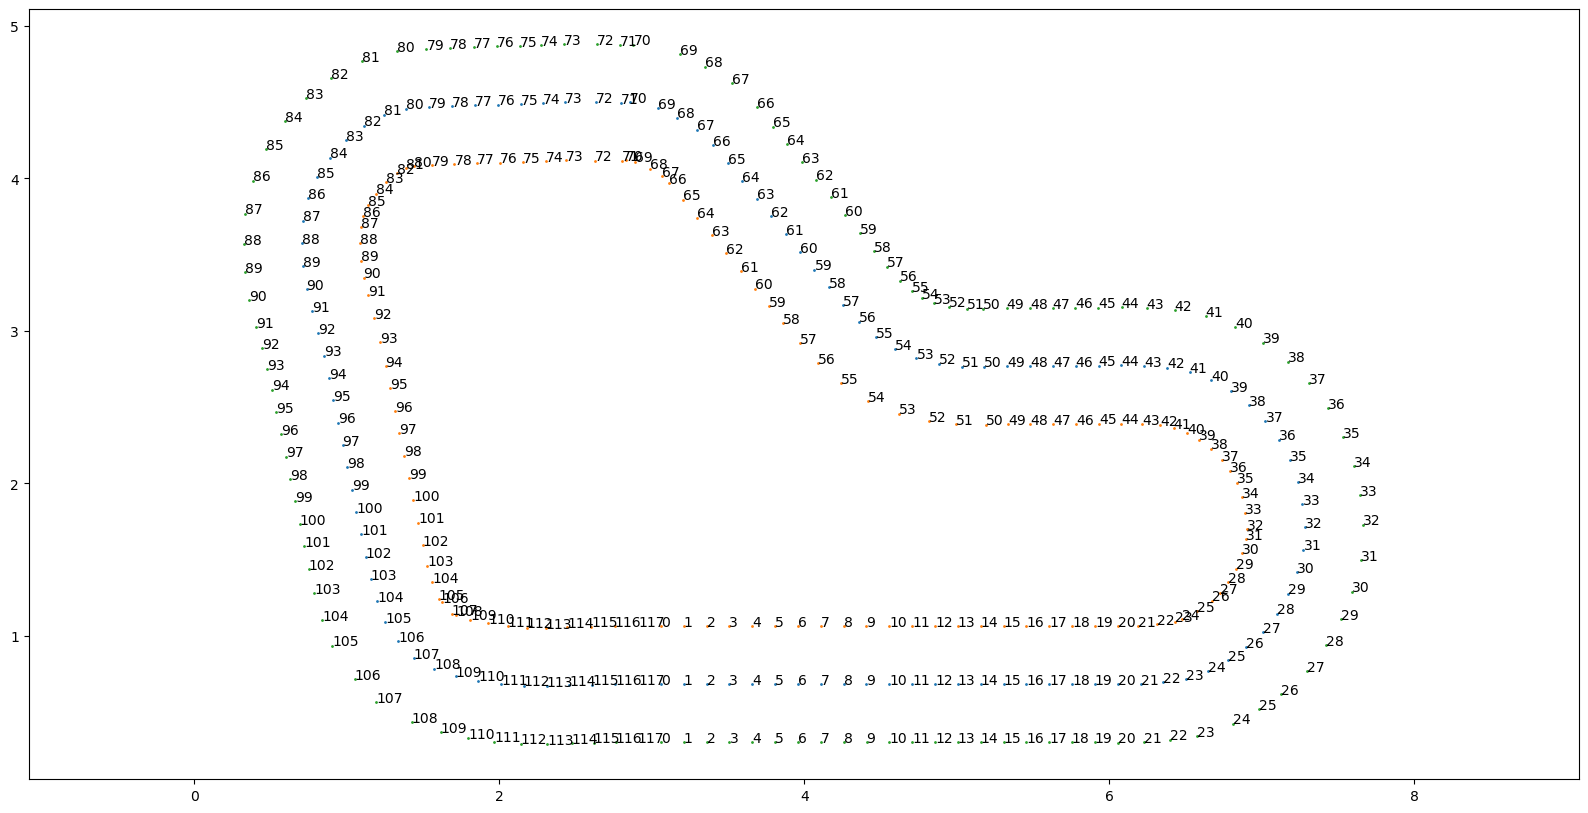

In [10]:
# Plot the results (center, inner, and outer waypoints)
fig, ax = plt.subplots(figsize=(20,10))
plot_points(ax, waypoints[:-1,0:2])
plot_points(ax, waypoints[:-1,2:4])
plot_points(ax, waypoints[:-1,4:6])
ax.axis('equal')
plt.show()

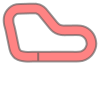

In [11]:
# Use Shapely to generate lines for the inner 
# and outer track borders, and centerline
l_center_line = LineString(waypoints[:,0:2])
l_inner_border = LineString(waypoints[:,2:4])
l_outer_border = LineString(waypoints[:,4:6])

# Create a shapely Polygon representing the track
road_poly = Polygon(np.vstack((l_outer_border.coords, np.flipud(l_inner_border.coords))))
road_poly

In [12]:
# Load waypoints (we will need these later to construct plots of the track)
center_line = waypoints[:,0:2] 
inner_border = waypoints[:,2:4]
outer_border = waypoints[:,4:6]

# Helper Functions 

In [13]:
# Plot the track shape
def plot_track(df, track_size=(500, 800), x_offset=0, y_offset=0, scale=100):
    '''
    Each track may have a diff track size, 
    For reinvent track, use track_size=(500, 800)
    Tokyo, track_size=(700, 1000)
    x_offset, y_offset is used to convert to the 0,0 coordinate system
    '''
    #track = np.zeros(track_size) # lets magnify the track by *100
    #for index, row in df.iterrows():
    #    x = int(row["x"]*scale + x_offset)
    #    y = int(row["y"]*scale + y_offset)
    #    reward = row["reward"]
    #    track[y, x] = reward
    #   plt.plot(y,x# ,reward)
    allx=[]
    ally=[]
    allreward=[]
    for index, row in df.iterrows():
        x = float(row["x"])
        y = float(row["y"])
        reward = float(row["reward"])
        allx.append(x)
        ally.append(y)
        allrewards=reward
        #track[y, x] = reward
        #plt.plot(y,x,reward)
    heatmap, xedges, yedges = np.histogram2d(allx, ally, bins=50)
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
        
    #fig = plt.figure(1, figsize=(12, 16))
    fig = plt.figure(1, figsize=track_size)
    ax = fig.add_subplot(111)
    print_border(ax, center_line, inner_border, outer_border)
    return heatmap.T,extent

In [14]:
# Plot the top N laps (5 by default)
def plot_top_laps(sorted_idx, n_laps=5):
    fig = plt.figure(n_laps, figsize=(12, 30))
    for i in range(n_laps):
        idx = sorted_idx[i]
        
        episode_data = episode_map[idx]
        
        ax = fig.add_subplot(n_laps,1,i+1)
        
        line = LineString(center_line)
        plot_coords(ax, line)
        plot_line(ax, line)
        
        line = LineString(inner_border)
        plot_coords(ax, line)
        plot_line(ax, line)

        line = LineString(outer_border)
        plot_coords(ax, line)
        plot_line(ax, line)

        for idx in range(1, len(episode_data)-1):
            x1,y1,action,reward,angle,speed = episode_data[idx]
            car_x2, car_y2 = x1 - 0.02, y1
            plt.plot([x1, car_x2], [y1, car_y2], 'b.')
        
    return fig

# Load Training Logs

In [15]:
EPISODE_PER_ITER = 20 if is_training else 1

In [16]:
# Create a Numpy array with raw data from each episode, including
# the (x,y) position of the car, yaw, steering angle, 
# throttle position, action, and reward
df = pd.read_csv(merged_simtrace_path)
iteration_arr = np.arange(math.ceil(df.episode.max()/EPISODE_PER_ITER)+1) * EPISODE_PER_ITER
df['iteration'] = np.digitize(df.episode, iteration_arr)
df = df.rename(columns={"X": "x", "Y": "y", "tstamp": "timestamp"})
df.head() # NOTE: We list only the first few rows, as the table can be thousands of rows long

,episode,steps,x,y,yaw,steer,throttle,action,reward,done,all_wheels_on_track,progress,closest_waypoint,track_len,timestamp,episode_status,pause_duration,iteration
0,0,1.0,3.199901,0.683114,0.182808,-1.470068,4.000000,"[-1.4700680247818312, 4.0]",0.000000,False,True,0.791503,1,17.709159,24.638,prepare,0.0,1
1,0,2.0,3.199733,0.683103,0.183266,-30.000000,1.000000,"[-30.0, 1.0]",0.236263,False,True,0.790551,1,17.709159,24.670,in_progress,0.0,1
2,0,3.0,3.209847,0.680486,-0.413327,-19.899546,1.305723,"[-19.899546198466474, 1.305723462944479]",0.387282,False,True,0.847641,1,17.709159,24.778,in_progress,0.0,1
3,0,4.0,3.231340,0.672382,-2.348847,-7.568222,4.000000,"[-7.568222091401548, 4.0]",1.731387,False,True,0.968938,1,17.709159,24.844,in_progress,0.0,1
4,0,5.0,3.273809,0.657694,-5.386425,13.581720,2.772500,"[13.58172040430771, 2.7724995392285243]",0.935599,False,True,1.208625,1,17.709159,24.871,in_progress,0.0,1


If the model used a continuous action space, we need to convert to a discrete action space by bucketing the actions into a discrete set. This will make it easier for us to generalize about the actions being taken by the car (i.e. are certain steering and throttle positions more commonly used? Are any portions of the action space being ignored?)

In [17]:
# Change these values to generate a more "fine grained" analysis
NUM_ANGLE_BUCKETS = 5
NUM_SPEED_BUCKETS = 4

if 'action_space_type' in model_metadata and model_metadata['action_space_type']=='continuous':
    max_angle = model_metadata['action_space']['steering_angle']['high']
    min_angle = model_metadata['action_space']['steering_angle']['low']

    max_speed = model_metadata['action_space']['speed']['high']
    min_speed = model_metadata['action_space']['speed']['low']

    #Determine which discrete bucket would be the equivalent for the continuous action space
    for index, row in df.iterrows():        
        angle_bucket = math.floor(((row["steer"] - min_angle)/(max_angle-min_angle))*NUM_ANGLE_BUCKETS)
        speed_bucket = math.floor(((row["throttle"] - min_speed)/(max_speed-min_speed))*NUM_SPEED_BUCKETS)
        if angle_bucket==NUM_ANGLE_BUCKETS:
            angle_bucket -= 1
        if speed_bucket==NUM_SPEED_BUCKETS:
            speed_bucket -= 1
        df.at[index,"action"] = int(angle_bucket*NUM_SPEED_BUCKETS+speed_bucket)
    

    #Convert the model metadata in memory to use the new forced discrete action space
    angle_bucket_size = (max_angle-min_angle)/NUM_ANGLE_BUCKETS
    angle = min_angle+.5*angle_bucket_size
    speed_bucket_size = (max_speed-min_speed)/NUM_SPEED_BUCKETS
    speed = min_speed+.5*speed_bucket_size    
    model_metadata['action_space'] = []
    index = 0
    for anglei in range(0,NUM_ANGLE_BUCKETS):
        for speed in range(0,NUM_SPEED_BUCKETS):
            model_metadata['action_space'].append({'index':index,
                                 'speed': speed,
                                 'steering_angle': angle})
            index+=1
            speed += speed_bucket_size
        angle += angle_bucket_size
        speed = min_speed+.5*speed_bucket_size
            
    print(df.head())

   episode  steps         x         y       yaw      steer  throttle action  \
0        0    1.0  3.199901  0.683114  0.182808  -1.470068  4.000000     11   
1        0    2.0  3.199733  0.683103  0.183266 -30.000000  1.000000      0   
2        0    3.0  3.209847  0.680486 -0.413327 -19.899546  1.305723      0   
3        0    4.0  3.231340  0.672382 -2.348847  -7.568222  4.000000      7   
4        0    5.0  3.273809  0.657694 -5.386425  13.581720  2.772500     14   

     reward   done  all_wheels_on_track  progress  closest_waypoint  \
0  0.000000  False                 True  0.791503                 1   
1  0.236263  False                 True  0.790551                 1   
2  0.387282  False                 True  0.847641                 1   
3  1.731387  False                 True  0.968938                 1   
4  0.935599  False                 True  1.208625                 1   

   track_len  timestamp episode_status  pause_duration  iteration  
0  17.709159     24.638       

In [18]:
# Normalize the rewards to a 0-1 scale
from sklearn.preprocessing import  MinMaxScaler
min_max_scaler = MinMaxScaler()
scaled_vals = min_max_scaler.fit_transform(df['reward'].values.reshape(df['reward'].values.shape[0], 1))
df['reward'] = pd.DataFrame(scaled_vals.squeeze())

## Plot the Rewards Earned Per Iteration

This graph is useful to understand the mean reward and standard deviation within each episode 

Number of episodes =  999
Minimum mean reward: 22.89609101602504
Maximum mean reward: 77.6230634787421


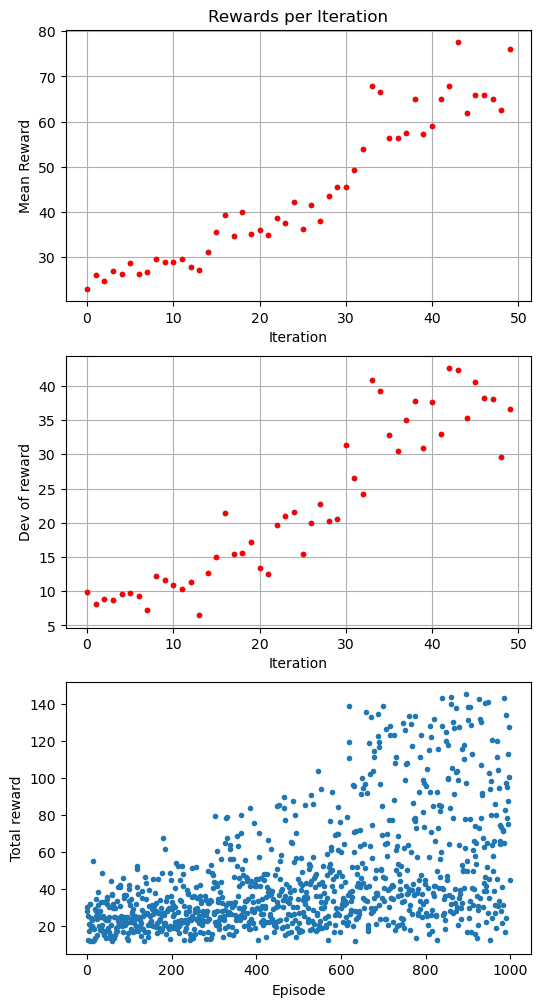

In [19]:
# This value adjusts the color used to plot mean reward
# rewards above this threshold value are plotted in RED
# while rewards below this threshold are plotted in BLUE
REWARD_THRESHOLD = 8

# Reward graph per episode
min_episodes = np.min(df['episode'])
max_episodes = np.max(df['episode'])
print('Number of episodes = ', max_episodes)

total_reward_per_episode = list()
    
for epi in np.arange(min_episodes, max_episodes+1,1):
    df_slice = df[df['episode'] == epi]
    total_reward_per_episode.append(np.sum(df_slice['reward']))

average_reward_per_iteration = list()
deviation_reward_per_iteration = list()

buffer_rew = list()
for val in total_reward_per_episode:
    buffer_rew.append(val)

    if len(buffer_rew) == EPISODE_PER_ITER:
        average_reward_per_iteration.append(np.mean(buffer_rew))
        deviation_reward_per_iteration.append(np.std(buffer_rew))
        # reset
        buffer_rew = list()

# Plot mean reward per iteration
fig = plt.figure(figsize=(6, 12))
ax = fig.add_subplot(311)
ax.plot(np.arange(len(average_reward_per_iteration)), average_reward_per_iteration, '.')
ax.set_title('Rewards per Iteration')
ax.set_ylabel('Mean Reward')
ax.set_xlabel('Iteration')

for rr in range(len(average_reward_per_iteration)):
    if average_reward_per_iteration[rr] >= REWARD_THRESHOLD:
        ax.plot(rr, average_reward_per_iteration[rr], 'r.')

plt.grid(True)

# Plot standard deviation of rewards per iteration
ax = fig.add_subplot(312)
ax.plot(np.arange(len(deviation_reward_per_iteration)), deviation_reward_per_iteration, '.')

ax.set_ylabel('Dev of reward')
ax.set_xlabel('Iteration')
plt.grid(True)

for rr in range(len(average_reward_per_iteration)):
    if average_reward_per_iteration[rr] >= REWARD_THRESHOLD:
        ax.plot(rr, deviation_reward_per_iteration[rr], 'r.')

# Plot total reward per episode
ax = fig.add_subplot(313)
ax.plot(np.arange(len(total_reward_per_episode)), total_reward_per_episode, '.')
ax.set_ylabel('Total reward')
ax.set_xlabel('Episode')

# Comment these two print statements in, to get an idea how to set your
# REWARD_THRESHOLD value
print('Minimum mean reward: {}'.format(min(average_reward_per_iteration)))
print('Maximum mean reward: {}'.format(max(average_reward_per_iteration)))

## Analyze training/evaluation metrics with progress and reward function

This graph gives you an idea whether your model has convergered or more training is required. If you see the curve trending upwards then more training time would help the agent to get better rewards

In [20]:
if is_training:
    METRIC_PATH = glob.glob("./{}/metrics/training/*.json".format(full_path))[0]
else:
    METRIC_PATH = glob.glob("./{}/metrics/evaluation/*.json".format(full_path))[0]
    
with open(METRIC_PATH, "r") as fp:
    data = json.loads(fp.read())
    metric_data = data['metrics']
    df_metrics = pd.DataFrame(metric_data)

if is_training:
    df_metrics = df_metrics[df_metrics['phase'] == "training"]

# Print a few rows from df_metrics, so we can see how the data is formatted
df_metrics

,reward_score,metric_time,start_time,elapsed_time_in_milliseconds,episode,trial,phase,completion_percentage,episode_status
0,15,27111,24587,2524,1,1,training,25,Off track
1,17,29512,27130,2382,2,2,training,21,Off track
2,18,31708,29578,2130,3,3,training,18,Off track
3,0,32844,31774,1070,4,4,training,4,Off track
4,-10,34704,32907,1797,5,5,training,16,Off track
...,...,...,...,...,...,...,...,...,...
1240,98,4651177,4641837,9340,996,16,training,83,Off track
1241,58,4657443,4651228,6215,997,17,training,56,Off track
1242,139,4667972,4657499,10473,998,18,training,100,Lap complete
1243,108,4676300,4668008,8292,999,19,training,70,Off track


Mean percentage: 32.058


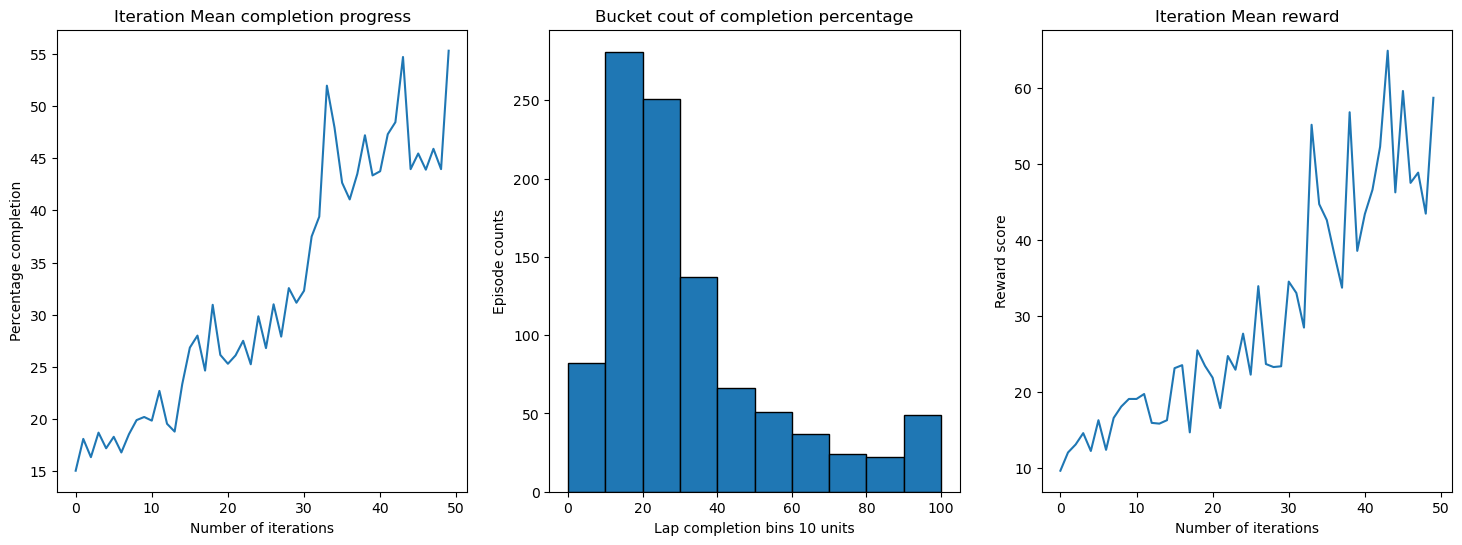

In [21]:
# Bins (for counting up track completion percentage by episode)
bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

df_metrics = df_metrics.sort_values(by="metric_time")
print('Mean percentage: {}'.format(df_metrics.completion_percentage.mean()))

completion_percentage_np = np.array(df_metrics.completion_percentage)
episode_progress_buckets = np.split(completion_percentage_np[:EPISODE_PER_ITER*(len(completion_percentage_np)//EPISODE_PER_ITER)],
                                    len(completion_percentage_np)//EPISODE_PER_ITER)
episode_progress_mean = np.mean(episode_progress_buckets, axis=1)

# Plot mean track completion per iteration
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
# Line graph showing the mean iteration of completion progress
ax1.plot(episode_progress_mean)
ax1.title.set_text('Iteration Mean completion progress')
ax1.set_xlabel('Number of iterations')
ax1.set_ylabel('Percentage completion')

# Bar chart to show completion_percentage with bucketing of 10% bar chart
ax2.hist(df_metrics.completion_percentage, bins=bins, edgecolor="k")
ax2.title.set_text('Bucket cout of completion percentage')
ax2.set_xlabel('Lap completion bins 10 units')
ax2.set_ylabel('Episode counts')

# Line graph showing the mean iteration of reward mean
if is_training:
    reward_score_np = np.array(df_metrics.reward_score)
    episode_reward_buckets = np.split(reward_score_np[:EPISODE_PER_ITER*(len(reward_score_np)//EPISODE_PER_ITER)],
                                                      len(reward_score_np)//EPISODE_PER_ITER)
    episode_reward_mean = np.mean(episode_reward_buckets, axis=1)
    ax3.plot(episode_reward_mean)
    plt.title("Metric analysis - Reward/percentage vs number of iterations")
    ax3.title.set_text('Iteration Mean reward')
    ax3.set_xlabel('Number of iterations')
    ax3.set_ylabel('Reward score')
    plt.show()


## Analyze Reward Function Reward Distribution (Plotted On The Track)

In [22]:
print("Min x-axis {}; Max x-axis {}".format(np.min(df['x']), np.max(df['x'])))
print("Min y-axis {}; Max y-axis {}".format(np.min(df['y']), np.max(df['y'])))

Min x-axis -0.0539799776375204; Max x-axis 8.014329395986238
Min y-axis -0.074297314476473; Max y-axis 5.233171963409095


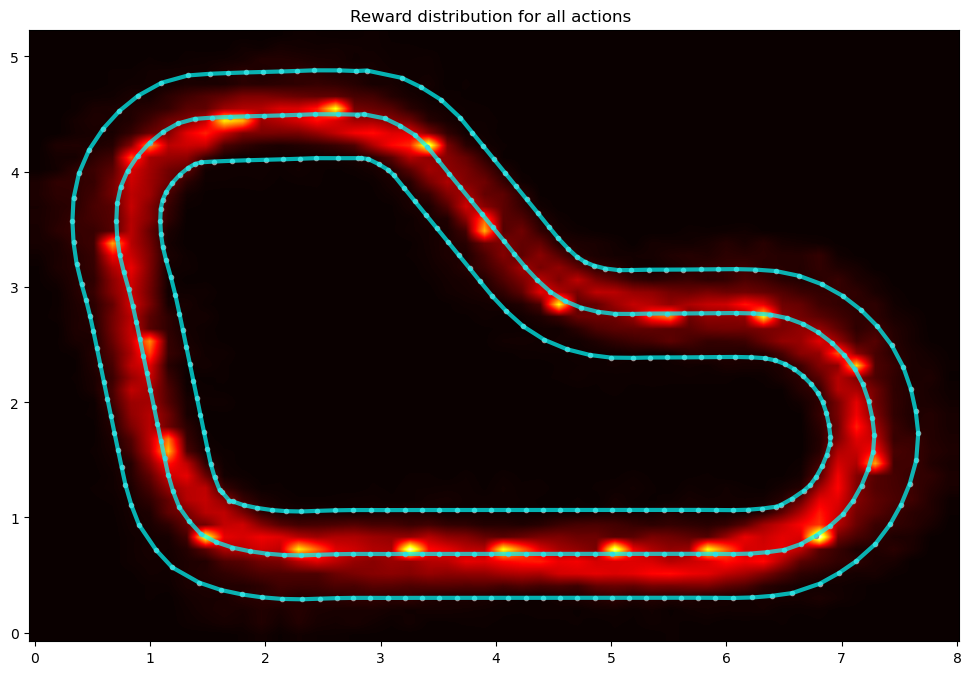

In [23]:
track,extent = plot_track(df, track_size=(12, 12), x_offset=0, y_offset=0)
plt.title("Reward distribution for all actions ")
im = plt.imshow(track, cmap='hot', extent=extent, interpolation='bilinear', origin="lower") 

### Plot A Specific Iteration

Iteration ID range: 1 to 50


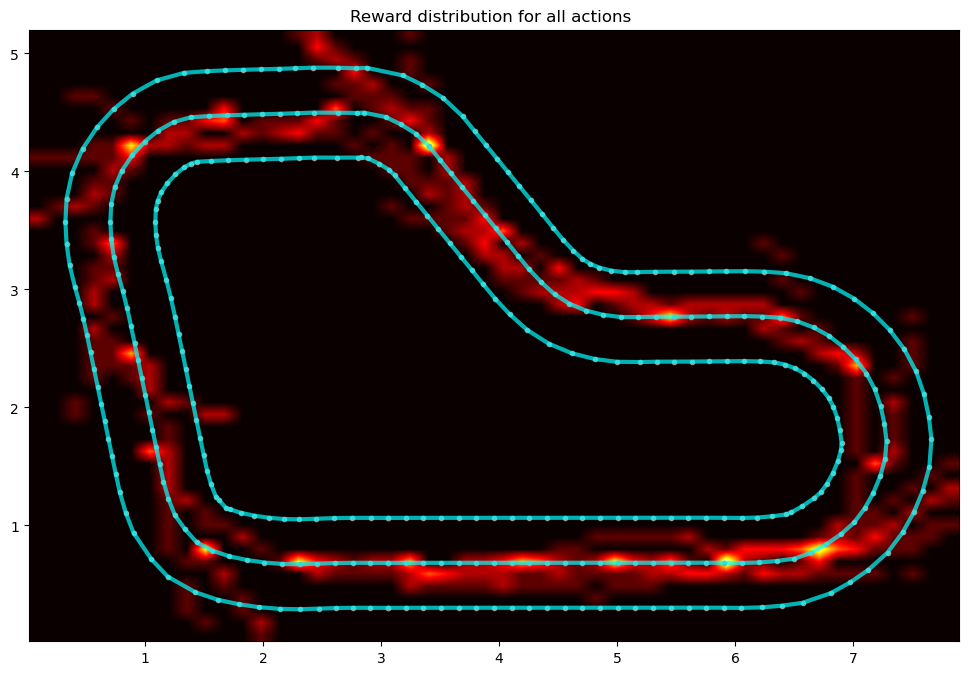

In [24]:
# Print out the minimum and maximum iteration IDs
print('Iteration ID range: 1 to {}'.format(df['iteration'].max()))

iteration_id = 3
track,extent = plot_track(df[df['iteration'] == iteration_id], track_size=(12, 12), x_offset=0, y_offset=0)
plt.title("Reward distribution for all actions ")
im = plt.imshow(track, cmap='hot', extent=extent, interpolation='bilinear', origin="lower") 

### Look At The Path Taken During Iterations That Earned A High Reward

NOTE: in a single episode, the car can go around multiple laps, the episode is terminated when the car completes 1000 steps

The top 3 highest reward episodes are [895, 859, 985]


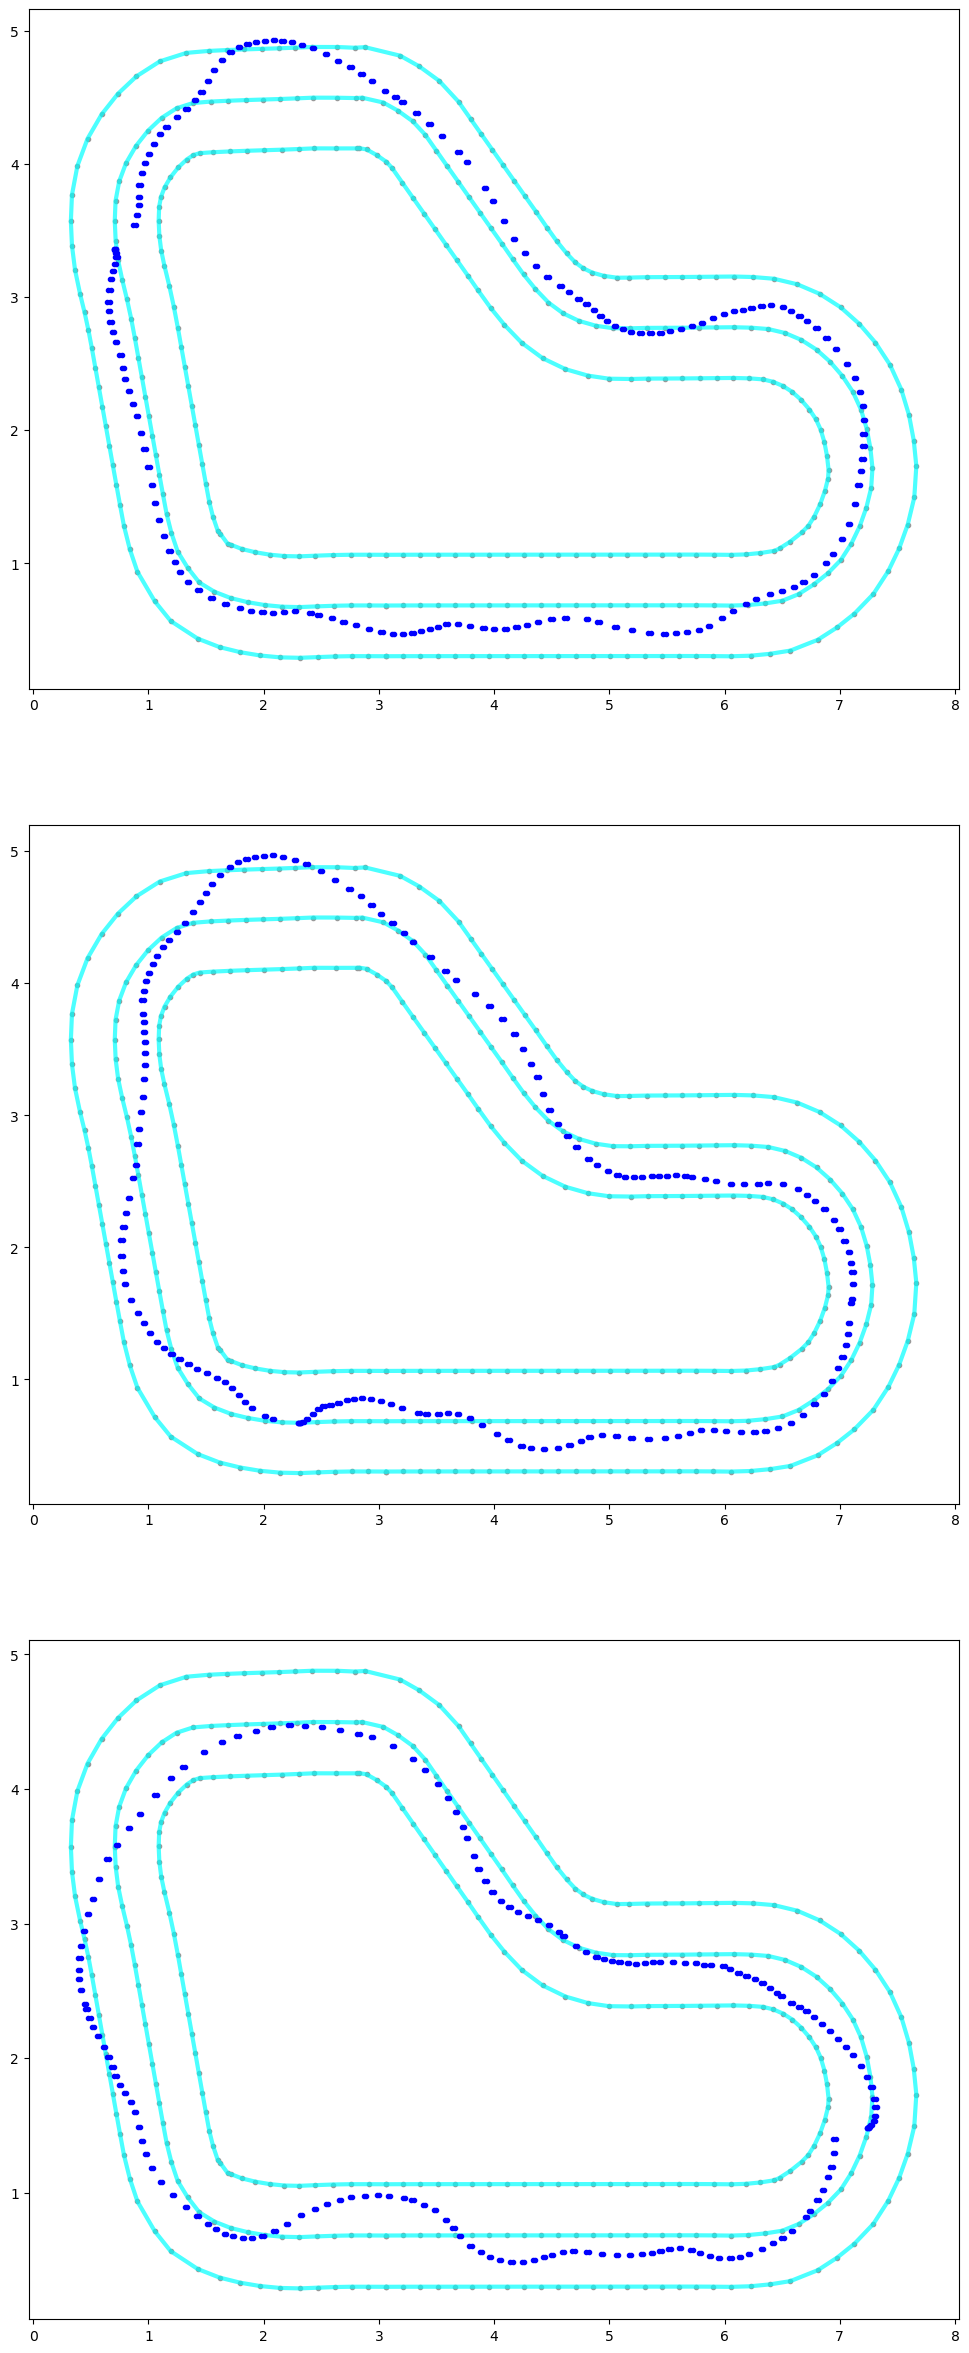

In [25]:
action_map, episode_map, sorted_idx = episode_parser(df)    
fig = plot_top_laps(sorted_idx[:], 3)
print("The top 3 highest reward episodes are {}".format(sorted_idx[:3]))

### Plot The Path Taken In A Particular Episode

In [26]:
def plot_episode_run(df, E):
    fig = plt.figure(1, figsize=(12, 16))
    ax = fig.add_subplot(211)
    print_border(ax, center_line, inner_border, outer_border) 
    episode_data = df[df['episode'] == E]
    for row in episode_data.iterrows():
        x1,y1,action,reward = row[1]['x'], row[1]['y'], row[1]['action'], row[1]['reward']
        car_x2, car_y2 = x1 - 0.02, y1
        plt.plot([x1, car_x2], [y1, car_y2], 'r.')

Max episode ID: 999


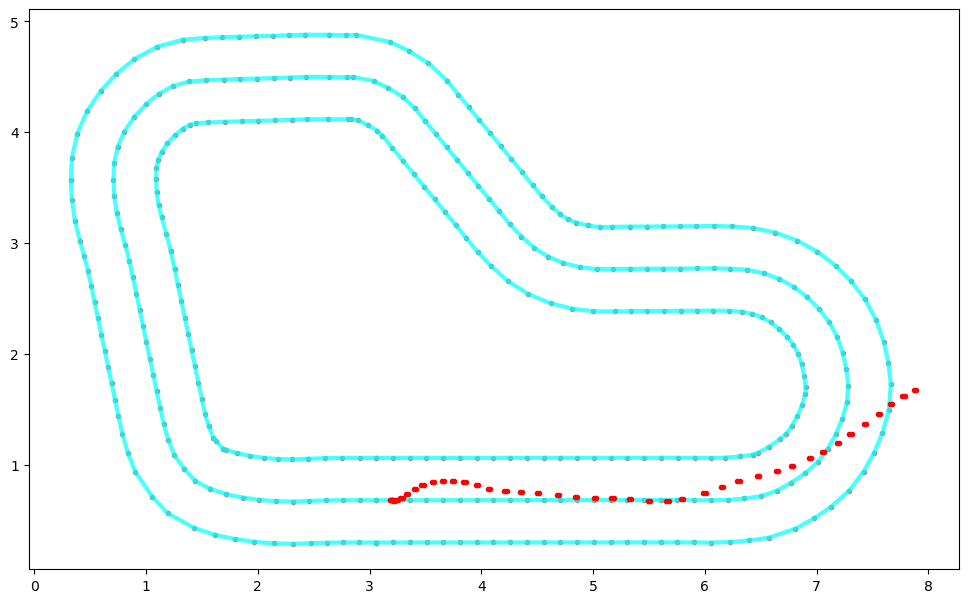

In [27]:
# Print the total number of episodes
print('Max episode ID: {}'.format(df['episode'].max()))

plot_episode_run(df, E=200) # Choose an arbitrary episode

## Action Breakdown (Per Iteration) With Action Distributoin Histogram

This plot is useful to understand the actions that the model takes for any given iteration.

Say you want the car to go at higher speeds on the straight line. This will give you an idea what actions the car is taking along those segments

In [28]:
# The actions plotted on the tracks may become noise. Use this to clip the low reward values action.
# Anything with reward < 0.8 is clipped. This is based on the reward function you trained on.
REWARD_THRESHOLD = 0.8
    
# Track Segment Labels
action_names = []
for action in model_metadata['action_space']:
    action_names.append("ST"+str(action['steering_angle'])+" SP"+"%.2f"%action["speed"])

print('Number of actions (or action buckets): {}'.format(len(action_names)))
action_names

Number of actions (or action buckets): 20


['ST-24.0 SP0.00',
 'ST-24.0 SP1.00',
 'ST-24.0 SP2.00',
 'ST-24.0 SP3.00',
 'ST-12.0 SP0.00',
 'ST-12.0 SP1.00',
 'ST-12.0 SP2.00',
 'ST-12.0 SP3.00',
 'ST0.0 SP0.00',
 'ST0.0 SP1.00',
 'ST0.0 SP2.00',
 'ST0.0 SP3.00',
 'ST12.0 SP0.00',
 'ST12.0 SP1.00',
 'ST12.0 SP2.00',
 'ST12.0 SP3.00',
 'ST24.0 SP0.00',
 'ST24.0 SP1.00',
 'ST24.0 SP2.00',
 'ST24.0 SP3.00']

**Define track labels**

This hash defines the labels for track segments on various tracks. **Analyzing new tracks will require adding a new entry to this hash.**

In [29]:
track_segments_hash = { "reinvent_base": [(0, 'straightaway'),
                                          (20, 'hairpin'),
                                          (46, 'slight right'),
                                          (61, 'left'),
                                          (76, 'slight left'),
                                          (90, 'straightaway'),
                                          (103, 'left'),
                                          (113, 'straightaway')                                         
                                          ],
                       "reInvent2019_track": [(0, 'left'),
                                              (18, 'sharp right'),
                                              (33, 'gentle left'),
                                              (82, 'left'),
                                              (93, 'slight left'),
                                              (107, 'left'),
                                              (117, 'right'),
                                              (137, 'left')
                                             ],
                       "arctic_open": [(0, 'straightaway'),
                                       (24,'left'),
                                       (36,'right'),
                                       (52,'left'),
                                       (67,'hairpin left'),
                                       (84,'right'),
                                       (98,'slight left'),
                                       (107,'straightaway'),
                                       (125,'slight left'),
                                       (134,'straightaway'),
                                       (156,'hairpin left')            
                       ],
                       "caecer_loop": [(0, 'straightaway'),
                                       (14,'slight left'),
                                       (34,'straightaway'),
                                       (42,'hairpin left'),
                                       (70,'straightaway'),
                                       (80,'sharp left'),
                                       (93,'straightaway'),
                                       (103,'slight left'),
                                       (115,'straightaway')            
                       ],
                       "red_star_open":[(0,'straightaway'),
                                        (29,'left'),
                                        (41,'straightaway'),
                                        (67,'hairpin left'),
                                        (78,'straightaway'),
                                        (94,'s-turn right'),
                                        (107,'s-turn left'),
                                        (119,'s-turn right'),
                                        (130,'s-turn left'),
                                        (140,'straightaway'),
                                        (155,'sharp left'),
                                        (163,'straightaway')                           
                       ]
}
trackname

'reinvent_base'

Number of steps in iteration = 617


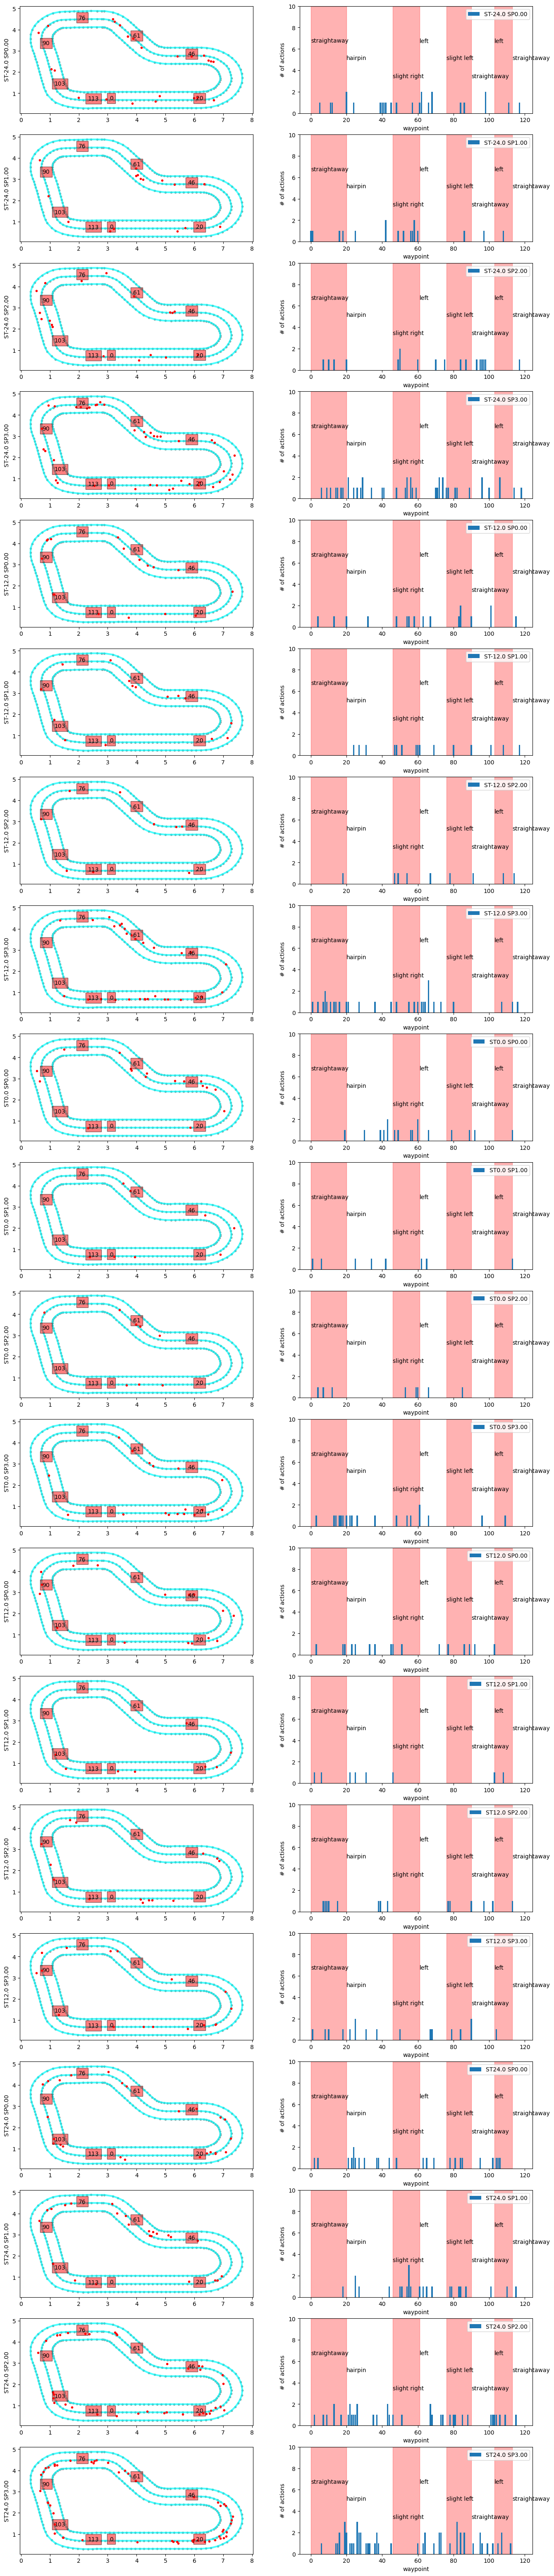

In [30]:
fig = plt.figure(figsize=(16, 4*len(action_names)))
iterations_downselect = [iteration_id] ## Lets pick the iteratons with the highest rewards

y_limit = 10
track_segments = track_segments_hash[trackname]
segment_x=[]
segment_y=[]
segment_xerr_l=[]
segment_xerr_r=[]
segment_yerr_n=[]
segment_yerr_s=[]
i=0
while i<len(track_segments):
    segment_x.append(track_segments[i][0])
    segment_y.append(0)
    segment_xerr_l.append(0)
    if i>=len(track_segments)-1:
        segment_xerr_r.append(len(waypoints)-track_segments[i][0])
    else:
        segment_xerr_r.append(track_segments[i+1][0]-track_segments[i][0])
    segment_yerr_n.append(0)
    segment_yerr_s.append(y_limit)
    i+=2

segment_x = np.array(segment_x)
segment_y = np.array(segment_y)
segment_xerr = np.array([segment_xerr_l,segment_xerr_r])
segment_yerr = np.array([segment_yerr_n,segment_yerr_s])

#segment_x = np.array(vert_lines)
#segment_y = np.array([0]*len(vert_lines))
#segment_xerr = np.array([[0]*len(vert_lines),[1]*len(vert_lines)])
#segment_yerr = np.array([[0]*len(vert_lines), [150]*len(vert_lines)])

wpts_array = center_line 
text_y=[.66*y_limit,.5*y_limit,.33*y_limit]
    
for iter_num in iterations_downselect:

    # Slice the data frame to get all episodes in that iteration
    df_iter = df[(iter_num == df['iteration'])]
    n_steps_in_iter = len(df_iter)
    print('Number of steps in iteration = {}'.format(n_steps_in_iter))

    # Reward function threshold
    th = REWARD_THRESHOLD
    for idx in range(len(action_names)):

        ax = fig.add_subplot(len(action_names), 2, 2*idx+1)
        print_border(ax, center_line, inner_border, outer_border) 
            
        df_slice = df_iter[df_iter['reward'] >= th]
        df_slice = df_slice[df_slice['action'] == idx]

        ax.plot(df_slice['x'], df_slice['y'], 'r.')

        for idWp in track_segments:
            ax.text(wpts_array[idWp[0]][0], wpts_array[idWp[0]][1], str(idWp[0]), bbox=dict(facecolor='red', alpha=0.5))

        #ax.set_title(str(log_name_id) + '-' + str(iter_num) + ' w rew >= '+str(th))
        ax.set_ylabel(action_names[idx])

        # calculate action way point distribution
        action_waypoint_distribution = list()
        for idWp in range(len(wpts_array)):
            action_waypoint_distribution.append(len(df_slice[df_slice['closest_waypoint'] == idWp]))

        ax = fig.add_subplot(len(action_names), 2, 2 * idx + 2)

        # Call function to create error boxes
        _ = make_error_boxes(ax, segment_x, segment_y, segment_xerr, segment_yerr)


        i=0
        for tt in range(len(track_segments)):
            ax.text(track_segments[tt][0], text_y[i], track_segments[tt][1])
            i = (i+1)%len(text_y)

        ax.bar(np.arange(len(wpts_array)), action_waypoint_distribution)
        ax.set_xlabel('waypoint')
        ax.set_ylabel('# of actions')
        ax.legend([action_names[idx]])
        ax.set_ylim((0, y_limit))

Lets analyze the actions chosen for each situation. Does this model choose to steer or go straight on straightaways? Does it choose to speed up or slow down? Are entire portions of the action space ignored, suggesting a mismatch between the action space at the reward function?